# Assignment 1: Naive Bayes classification {-}

This assignment aims at familiarizing you with training and testing Naive Bayes model. The dataset you will be working on is 'travel-insurance.csv'. It is composed of attributes such as age, employment type, etc, to predict if a customer is going to buy a travel insurance. You will have to do:
1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Load the travel-insurance.csv dataset and perform basic data cleaning, analysis and visualization to have a deep understanding about the data.  
    1.2 *(1 point)* Preprocess the data for modeling; divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    1.3 *(1 point)* Train a Gaussian Naive Bayes (GaussianNB, https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) model and find the best set of hyperparameters (var_smoothing hyperparameter) using validation set and cross validation technique (see GridSearchCV).  
    1.4 *(1 point)* Train a Mixed Naive Bayes (MixedNB, https://pypi.org/project/mixed-naive-bayes/) model.  
    1.5 *(1 point)* Evaluate and compare the model performance of GaussianNB and MixedNB on the test set using the following metrics: precision, recall, f1-score.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* Which features in the dataset do you think have the most impact on predicting whether a customer buys travel insurance? Why?  
    2.2 *(1 point)* The Naive Bayes classifier assumes feature independence. Do you think this assumption holds for this dataset? Justify your answer.  
    2.3 *(1 point)* Did you observe any surprising patterns or trends in the dataset while exploring the data? Provide examples and possible explanations.  
    2.4 *(1 point)* How did tuning the var_smoothing parameter affect the performance of GaussianNB? What strategy did you use to find the best value?  
    2.5 *(1 point)* Do you think this dataset is sufficient for accurately predicting travel insurance purchases? What additional data points would you collect to improve prediction accuracy?  

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment1-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named ML4DS-\<StudentID>-Assignment1 (e.g., ML4DS-2012345-Assigment1) and then compressed with the same name.
    
### Evaluation {-}
Assignment evaluation will be conducted on how properly you handle the data for training and testing purpose, build a Naive Bayes classifier and evaluate the model performance. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("travel-insurance.csv")
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


Here follows the list of columns in the dataset:

* Age - Age of the customer
* Employment Type - The sector in which customer is employed
* GraduateOrNot - Whether the customer is college graduate or not
* AnnualIncome - The yearly income of the customer in indian rupees
* FamilyMembers - Number of members in customer's family
* ChronicDisease - Whether the customer suffers from any major disease or conditions like diabetes/high BP or asthama, etc.
* FrequentFlyer - Derived data based on customer's history of booking air tickets on atleast 4 different instances in the last 2 Years (2017-2019).
* EverTravelledAbroad - Has the customer ever travelled to a foreign country.
* TravelInsurance: (label) Did the customer buy travel insurance package during introductory offering held in the year 2019.

## 1. Coding tasks

In [4]:
# Your code goes here
# 1.1
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Dataset shape: (1987, 10)

Missing values:
 Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

Data types:
 Unnamed: 0              int64
Age                     int64
Employment Type        object
GraduateOrNot          object
AnnualIncome            int64
FamilyMembers           int64
ChronicDiseases         int64
FrequentFlyer          object
EverTravelledAbroad    object
TravelInsurance         int64
dtype: object


In [5]:
print("\nStatistical summary (numeric):\n", df.describe())



Statistical summary (numeric):
         Unnamed: 0          Age  AnnualIncome  FamilyMembers  ChronicDiseases  \
count  1987.000000  1987.000000  1.987000e+03    1987.000000      1987.000000   
mean    993.000000    29.650226  9.327630e+05       4.752894         0.277806   
std     573.741812     2.913308  3.768557e+05       1.609650         0.448030   
min       0.000000    25.000000  3.000000e+05       2.000000         0.000000   
25%     496.500000    28.000000  6.000000e+05       4.000000         0.000000   
50%     993.000000    29.000000  9.000000e+05       5.000000         0.000000   
75%    1489.500000    32.000000  1.250000e+06       6.000000         1.000000   
max    1986.000000    35.000000  1.800000e+06       9.000000         1.000000   

       TravelInsurance  
count      1987.000000  
mean          0.357323  
std           0.479332  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           1.000000  
max           1.000000  


In [6]:
print("\nValue counts - Travel Insurance:\n", df["TravelInsurance"].value_counts(normalize=True))



Value counts - Travel Insurance:
 TravelInsurance
0    0.642677
1    0.357323
Name: proportion, dtype: float64


This indicates that the majority of customers chose not to purchase travel insurance. The adoption rate of travel insurance is relatively low (just over one-third of customers). The analysis suggests that the level of interest in and perceived importance of travel insurance among the majority of individuals remains relatively low. One of the most significant is the economic impact of the COVID-19 pandemic. In the post-pandemic period, the overall economic environment has the tendency to decline dramatically, leading to the result that households and individuals have been prioritizing financial recovery, with limited disposable income available for additional considerations such as purchasing travel insurance. The relatively low uptake may also signal a risk perception gap: customers may underestimate travel risks or feel that insurance does not provide sufficient value for its cost.

Correlation of numeric features with TravelInsurance:
TravelInsurance    1.000000
AnnualIncome       0.396763
FamilyMembers      0.079909
Age                0.061060
ChronicDiseases    0.018190
Unnamed: 0         0.006196
Name: TravelInsurance, dtype: float64


/tmp/ipython-input-1974142690.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="coolwarm")


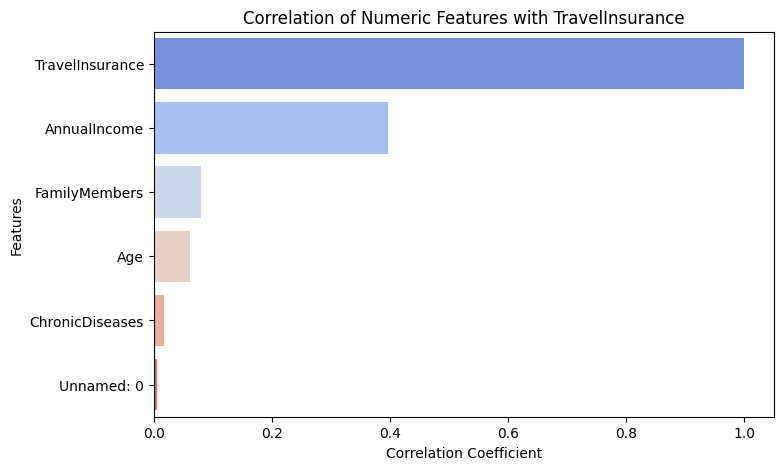

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure TravelInsurance is numeric (0/1)
df["TravelInsurance"] = pd.to_numeric(df["TravelInsurance"], errors="coerce")

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with TravelInsurance
corr_with_target = numeric_df.corr()["TravelInsurance"].sort_values(ascending=False)

print("Correlation of numeric features with TravelInsurance:")
print(corr_with_target)

# Plot bar chart of correlations
plt.figure(figsize=(8,5))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="coolwarm")
plt.title("Correlation of Numeric Features with TravelInsurance")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()



To better understand the relationship between numeric features and the target variable (TravelInsurance), correlation coefficients were calculated. The results are visualized in the correlation chart. The correlation analysis indicates that income is the most influential numeric factor in predicting travel insurance adoption. Other demographic features such as age, family size, and chronic disease status have little explanatory power when considered individually.

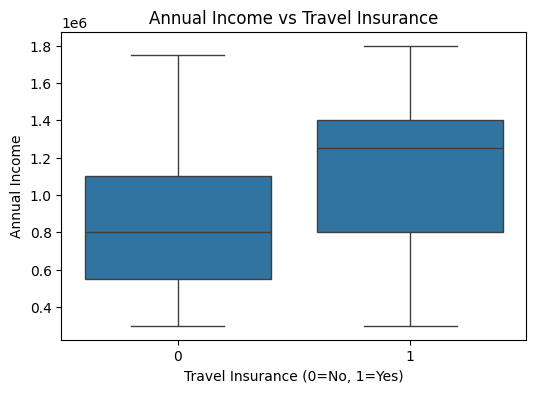

In [8]:
# 1. Travel Insurance vs Annual Income
plt.figure(figsize=(6,4))
sns.boxplot(x="TravelInsurance", y="AnnualIncome", data=df)
plt.title("Annual Income vs Travel Insurance")
plt.xlabel("Travel Insurance (0=No, 1=Yes)")
plt.ylabel("Annual Income")
plt.show()


The boxplot comparing Annual Income with Travel Insurance purchase (0 = No, 1 = Yes) reveals several key insights. Individuals who purchased travel insurance (1) generally have a higher median annual income compared to those who did not (0).This confirms the earlier correlation analysis, where Annual Income showed the strongest positive association with Travel Insurance uptake.Despite the clear income gap, overlap exists: some low-income individuals still purchase insurance, while some high-income individuals choose not to.This indicates that income alone cannot fully explain purchasing decisions; additional demographic and behavioral factors likely influence the outcome.

Employment Type:
Employment Type
Government Sector               0.245614
Private Sector/Self Employed    0.402258
Name: TravelInsurance, dtype: float64
Impact Score = 0.16

GraduateOrNot:
GraduateOrNot
No     0.335593
Yes    0.361111
Name: TravelInsurance, dtype: float64
Impact Score = 0.03

FrequentFlyer:
FrequentFlyer
No     0.300000
Yes    0.573141
Name: TravelInsurance, dtype: float64
Impact Score = 0.27

EverTravelledAbroad:
EverTravelledAbroad
No     0.256378
Yes    0.784211
Name: TravelInsurance, dtype: float64
Impact Score = 0.53

Ranking of categorical features by impact on TravelInsurance:
EverTravelledAbroad: 0.53
FrequentFlyer: 0.27
Employment Type: 0.16
GraduateOrNot: 0.03


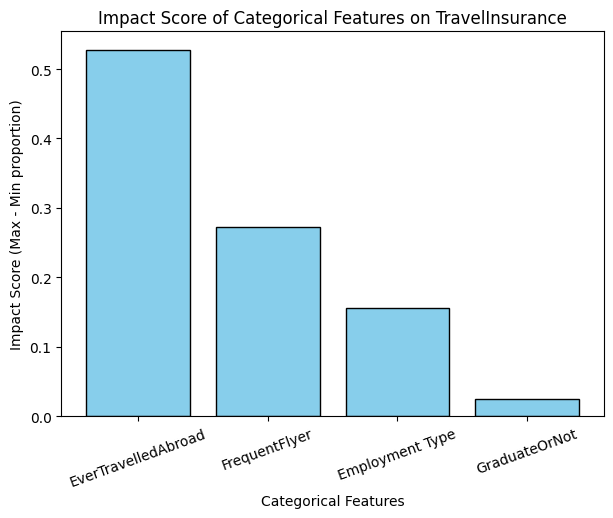

In [9]:
categorical_cols = ["Employment Type", "GraduateOrNot", "FrequentFlyer", "EverTravelledAbroad"]

impact_scores = {}

for col in categorical_cols:
    # Calculate the proportion of TravelInsurance=1 for each category
    prop = df.groupby(col)["TravelInsurance"].mean()

    # Calculate impact score (difference between max and min proportion)
    impact = prop.max() - prop.min()
    impact_scores[col] = impact

    print(f"{col}:\n{prop}\nImpact Score = {impact:.2f}\n")

# Rank categorical variables by impact score
impact_sorted = sorted(impact_scores.items(), key=lambda x: x[1], reverse=True)
print("Ranking of categorical features by impact on TravelInsurance:")
for col, score in impact_sorted:
    print(f"{col}: {score:.2f}")
# ---- Plotting ----
# Convert to dict for plotting
impact_sorted_dict = dict(impact_sorted)

plt.figure(figsize=(7,5))
plt.bar(impact_sorted_dict.keys(), impact_sorted_dict.values(), color="skyblue", edgecolor="black")
plt.title("Impact Score of Categorical Features on TravelInsurance")
plt.ylabel("Impact Score (Max - Min proportion)")
plt.xlabel("Categorical Features")
plt.xticks(rotation=20)
plt.show()


The analysis of travel insurance data reveals that the decision to purchase insurance is primarily influenced by financial and travel-related factors. Among numeric features, annual income shows the strongest positive correlation, indicating that individuals with higher income are more likely to buy travel insurance, while age, family size, and chronic diseases have less impact. For categorical features, travel experience plays a key role that those who have traveled abroad or are frequent flyers are significantly more inclined to purchase insurance, whereas employment type has a moderate effect and education level shows almost no influence. Overall, the findings suggest that travel insurance uptake is driven more by financial capacity and exposure to international travel rather than demographic or health-related variables.


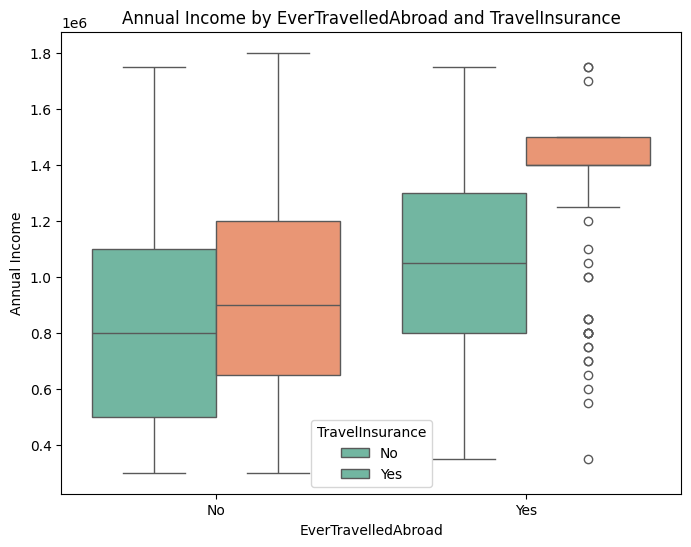

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="EverTravelledAbroad",
    y="AnnualIncome",
    hue="TravelInsurance",
    palette="Set2"
)

plt.title("Annual Income by EverTravelledAbroad and TravelInsurance")
plt.xlabel("EverTravelledAbroad")
plt.ylabel("Annual Income")
plt.legend(title="TravelInsurance", labels=["No", "Yes"])
plt.show()


This boxplot illustrates the relationship between annual income, prior international travel experience, and the decision to purchase travel insurance. For individuals who have not traveled abroad, the income distribution shows that those with higher income are slightly more likely to buy insurance compared to lower-income groups, but the gap between insured and non-insured groups remains large. In contrast, in the travelled-abroad group, there is a clearer separation: insured individuals tend to have consistently higher annual incomes, while non-insured travelers display a wider spread with many lower-income cases. This suggests that both income level and prior international travel experience are strong factors influencing the likelihood of purchasing travel insurance, with the effect being most pronounced among those with global travel exposure.


In [11]:
# Your code goes here
# 1.2
# Identify categorical columns (adjust to match your dataset)
categorical_cols = ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_dict = {}
for col in categorical_cols:
    if df[col].dtype == "object":   # only encode if it's not numeric
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# Double check all features are numeric
print(df.dtypes)
# Separate target
X = df.drop("TravelInsurance", axis=1)
y = df["TravelInsurance"]

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print(X.head())


Unnamed: 0             int64
Age                    int64
Employment Type        int64
GraduateOrNot          int64
AnnualIncome           int64
FamilyMembers          int64
ChronicDiseases        int64
FrequentFlyer          int64
EverTravelledAbroad    int64
TravelInsurance        int64
dtype: object
   Unnamed: 0  Age  Employment Type  GraduateOrNot  AnnualIncome  \
0           0   31                0              1        400000   
1           1   31                1              1       1250000   
2           2   34                1              1        500000   
3           3   28                1              1        700000   
4           4   28                1              1        700000   

   FamilyMembers  ChronicDiseases  FrequentFlyer  EverTravelledAbroad  
0              6                1              0                    0  
1              7                0              0                    0  
2              4                1              0                    0  

In [12]:
from sklearn.model_selection import train_test_split

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (1589, 9) (1589,)
Test shape: (398, 9) (398,)


In [13]:
# Your code goes here
!pip install mixed-naive-bayes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from mixed_naive_bayes import MixedNB
from sklearn.metrics import classification_report


In [14]:
# 1.3
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]}
gnb = GaussianNB()
grid_gnb = GridSearchCV(gnb, param_grid, cv=5, scoring='f1')
grid_gnb.fit(X_train, y_train)

best_gnb = grid_gnb.best_estimator_
print("Best GaussianNB params:", grid_gnb.best_params_)

Best GaussianNB params: {'var_smoothing': 1e-09}


In [15]:
# Your code goes here
# 1.4
# Find the indices of the one-hot encoded categorical columns
categorical_cols_encoded = [col for col in X_train.columns if any(cat in col for cat in categorical_cols)]
categorical_idx = [X_train.columns.get_loc(c) for c in categorical_cols_encoded]

mnb = MixedNB(categorical_features=categorical_idx)
mnb.fit(X_train, y_train)

MixedNB(alpha=0.5, var_smoothing=1e-09)

In [16]:
# Your code goes here
# 1.5
y_pred_gnb = best_gnb.predict(X_test)
y_pred_mnb = mnb.predict(X_test)

print("\n--- GaussianNB Report ---")
print(classification_report(y_test, y_pred_gnb))

print("\n--- MixedNB Report ---")
print(classification_report(y_test, y_pred_mnb))


--- GaussianNB Report ---
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       256
           1       0.68      0.51      0.58       142

    accuracy                           0.74       398
   macro avg       0.72      0.69      0.70       398
weighted avg       0.73      0.74      0.73       398


--- MixedNB Report ---
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       256
           1       0.73      0.53      0.61       142

    accuracy                           0.76       398
   macro avg       0.75      0.71      0.72       398
weighted avg       0.76      0.76      0.75       398



## 2. Open discussion questions

In [17]:
# Your argument goes here
# 2.1
df.groupby("TravelInsurance")[["Age", "AnnualIncome", "FrequentFlyer"]].mean()


,Age,AnnualIncome,FrequentFlyer
TravelInsurance,,,
0,29.517619,8.212999e+05,0.139389
1,29.888732,1.133239e+06,0.336620


First, the average annual income reflects people’s willingness to spend on items that are often considered non-essential, including travel insurance. From the results of the code we ran, we can observe a significant gap in the average income between the groups who purchased and did not purchase insurance. This is understandable, as the general mindset is to prioritize spending on basic necessities before considering what might be viewed as more “luxurious” products like travel insurance. Wealthier individuals, in contrast, are more likely to allocate additional resources to protective measures for their health and safety.

Another factor that strongly influences the decision to purchase travel insurance is how frequently an individual travels. For those with stable jobs that do not require frequent business trips, buying insurance for just two or three travels a year may seem unnecessary or even wasteful. Moreover, most people do not anticipate being “unlucky” enough to encounter accidents during such a small number of trips. In contrast, individuals who travel frequently, whether for work or lifestyle reasons, see traveling as a regular part of their lives. For them, purchasing travel insurance becomes a practical way to safeguard themselves against potential risks. As a result, this group is more likely to allocate funds toward travel insurance compared to those who travel infrequently.

Finally, age also appears to have a modest influence on the likelihood of purchasing travel insurance. Although the difference is not very large, the data shows that individuals who purchase insurance tend to be slightly older on average. This may be explained by the fact that, as people age, they tend to value their health and safety more, or they may have greater travel demands such as visiting their children, attending business trips, or taking leisure vacations to reduce stress. However, these are only general tendencies. Younger individuals may also share similar concerns and motivations. Ultimately, while it is reasonable to assume that everyone values their life and safety, a combination of financial, occupational, and personal priorities often determines whether travel insurance is included in their purchase plan.

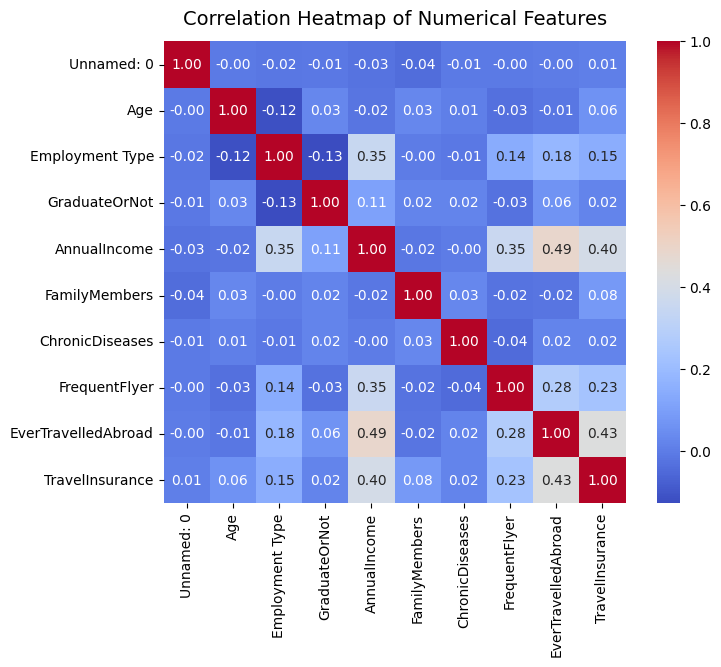

In [18]:
# Your argument goes here
# 2.2
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, pad=12)
plt.show()


The Naive Bayes classifier assumes that features are conditionally independent given the target variable. However, based on both exploratory data analysis (Section 2.1) and the correlation heatmap, this assumption does not strictly hold in our dataset.

For instance, we observed that individuals with higher annual income are also more likely to purchase travel insurance. At the same time, income is correlated with travel habits, as wealthier individuals often travel abroad more frequently and are more likely to be frequent flyers. These patterns are confirmed in the heatmap: AnnualIncome has a correlation of ~0.49 with EverTravelledAbroad and ~0.35 with FrequentFlyer.

Therefore, we can conclude that the independence assumption of Naive Bayes is violated in this dataset, especially among features such as AnnualIncome, EverTravelledAbroad, and FrequentFlyer. While Naive Bayes may still provide a baseline performance due to its robustness, models that can explicitly capture feature dependencies (such as Logistic Regression, Decision Trees, or ensemble methods) are likely to perform better.

In [19]:
# Your argument goes here
# 2.3
# Check correlation of GraduateOrNot and Employment Type with TravelInsurance
corr_matrix = df.corr(numeric_only=True)
print("Correlation(GraduateOrNot, TravelInsurance):", corr_matrix.loc["GraduateOrNot","TravelInsurance"])
print("Correlation(Employment Type, TravelInsurance):", corr_matrix.loc["Employment Type","TravelInsurance"])

# Or compare average values by TravelInsurance group
print("\nMean GraduateOrNot by TravelInsurance:")
print(df.groupby("TravelInsurance")["GraduateOrNot"].mean())

print("\nMean Employment Type by TravelInsurance:")
print(df.groupby("TravelInsurance")["Employment Type"].mean())


Correlation(GraduateOrNot, TravelInsurance): 0.018933518941987925
Correlation(Employment Type, TravelInsurance): 0.14784689471091722

Mean GraduateOrNot by TravelInsurance:
TravelInsurance
0    0.846515
1    0.860563
Name: GraduateOrNot, dtype: float64

Mean Employment Type by TravelInsurance:
TravelInsurance
0    0.663273
1    0.802817
Name: Employment Type, dtype: float64


In common thinking, we often assume that individuals who have graduated and those working in the private sector are more likely to have higher travel demands, given their job requirements and income levels. However, the results here indicate that these two factors have little to no significant impact on the decision to purchase travel insurance. The correlation coefficients between both variables and TravelInsurance are very weak (≈ 0.02 for GraduateOrNot and ≈ 0.15 for Employment Type), suggesting that education level and job type play a negligible role compared to stronger determinants like annual income and travel frequency. Even when comparing mean values between groups, the differences are minimal, further reinforcing that financial capacity and lifestyle factors are much more decisive in shaping purchasing behavior.

In [20]:
# Your argument goes here
# 2.4


In Question 1.3, we performed hyperparameter tuning for the Gaussian Naive Bayes model using GridSearchCV across a range of var_smoothing values ([1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]). The search result indicated that the best performing parameter was 1e-9. This finding reveals that the dataset already provides relatively stable variance estimates for its numerical features. As a result, the model achieves its highest performance when only a minimal amount of smoothing is applied. The small but non-zero smoothing value of 1e-09 is just enough to safeguard against numerical instability without compromising the natural separation in the data.

Cross-validation over a range of smoothing values was the tuning approach that made sure the selected parameter performed well not only on the training dataset but also on others.  In this case, it also showed that GaussianNB can efficiently model the dataset without requiring a lot of regularization, indicating that factors like age, travel frequency, and annual income already provide significant, distinct signals for prediction.



In [21]:
# Your argument goes here
# 2.5

While the dataset provides valuable demographic and travel-related variables, it is not fully sufficient for highly accurate prediction of travel insurance purchase decisions. The data is largely structural (age, income, education, travel history), but insurance decisions are also strongly influenced by psychological, behavioral, and contextual factors.

Insurance purchase history: prior exposure to similar insurance products (namely building or vehicle insurance) is often a strong predictor for future purchases.

Another important aspect that could be added to the dataset is travel purpose and activity type. Business travelers may already be covered by employer-provided insurance, which could lower their likelihood of making an additional purchase. In contrast, leisure travelers are more likely to self-purchase insurance, especially if their trips involve high-risk activities. For example, a person going on a vacation that includes adventurous activities such as hiking, diving, or extreme sports may perceive greater risks and therefore have a stronger tendency to purchase travel insurance. In this way, the inclusion of trip details would enrich the dataset by directly capturing the risk exposure associated with different types of travel.

Geographic region or residence type: cultural and regional factors (urban vs. rural) can shape attitudes toward insurance. Rural residents, who often live in relatively peaceful and safe environments, may develop a sense of complacency regarding travel risks. As a result, they may be less willing to purchase travel insurance or may not perceive it as necessary. In contrast, urban residents, who are generally more exposed to diverse risks and are more familiar with insurance products, may have a stronger inclination toward purchasing travel insurance. Including this variable could therefore reveal important behavioral differences across demographic groups.

In addition, the influence of marketing and advertising activities should not be overlooked. Although in recent decades, the insurance industry (not only travel insurance) has faced controversial debates regarding its reputation, advertising campaigns still play a crucial role in shaping consumers’ awareness and purchase decisions. As a feature, exposure to insurance marketing could be valuable in analyzing purchasing tendencies. For instance, combining this factor with education level may reveal interesting insights: individuals with higher education may be better equipped to evaluate the credibility and benefits of different insurance services, while those with less education may be more susceptible to distrust or misinformation. Thus, incorporating marketing influence alongside demographic variables could enrich the predictive power of the dataset.


Incorporating these behavioral and contextual dimensions would enable more accurate modeling by capturing the true drivers of insurance decisions, beyond just demographics.